# Training Neural Networks with PyTorch — From Raw Tensors to `nn.Module`

Now that we understand what neurons, weights, biases, activation functions, and layers do — let's train a **real neural network** on a **real dataset**.

We'll do this in **three stages**, each building on the last:

| Stage | What We Do | Why |
|-------|-----------|-----|
| **Stage 1** | Build the network using raw PyTorch tensors, use `.backward()` for gradients | See exactly what's happening under the hood |
| **Stage 2** | Refactor into `nn.Module` with proper layers | The clean, professional way to build networks |
| **Stage 3** | Add training best practices (DataLoader, optimizer, etc.) | How real-world training is done |

**Dataset**: MNIST — 70,000 handwritten digit images (28×28 pixels), classify into digits 0–9.

---

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# use mps
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0
CUDA available: False
Using device: mps


## Loading MNIST

Each image is 28×28 = **784 pixels**. We'll **flatten** each image into a vector of 784 numbers. Each pixel is a value between 0 (black) and 1 (white).

The label is a digit from 0 to 9 — so our network needs **10 output neurons**, one per class.

In [2]:
# Download and load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),           # Convert image to tensor (also scales to 0-1)
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape:      {train_dataset[0][0].shape}  (channels, height, width)")
print(f"Flattened:        {28*28} = 784 input features")
print(f"Classes:          0-9 (10 digits)")

Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])  (channels, height, width)
Flattened:        784 = 784 input features
Classes:          0-9 (10 digits)


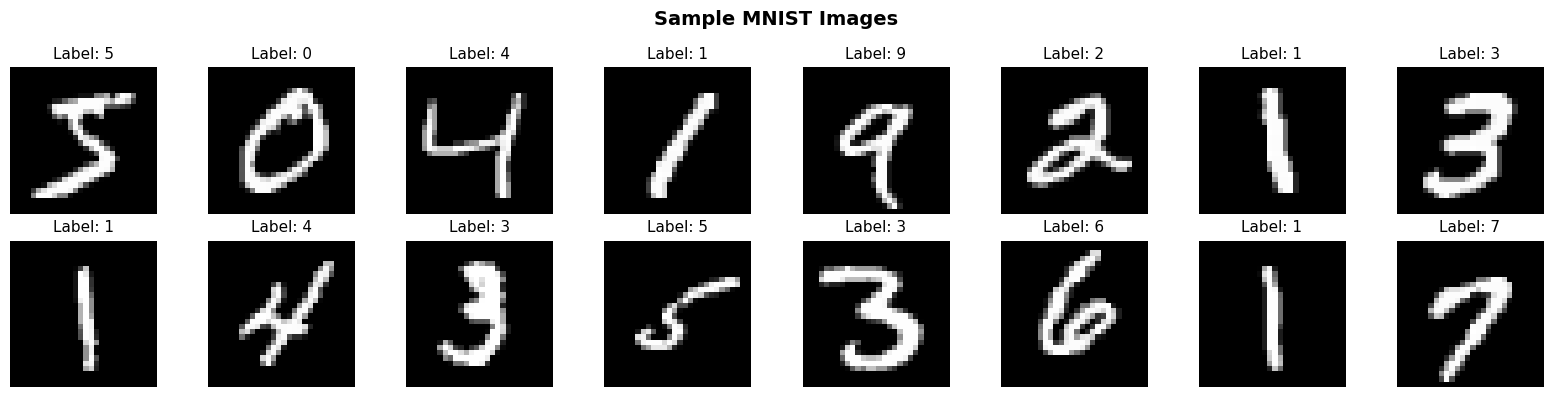

In [3]:
# Let's look at some examples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=11)
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# Prepare the FULL dataset as tensors for Stage 1 (manual training)
# We load everything into memory at once for simplicity

X_train = train_dataset.data.float() / 255.0   # Normalize to 0-1
X_train = X_train.view(-1, 784)                 # Flatten: (60000, 28, 28) → (60000, 784)
y_train = train_dataset.targets                  # Labels: (60000,)

X_test = test_dataset.data.float() / 255.0
X_test = X_test.view(-1, 784)
y_test = test_dataset.targets

print(f"X_train shape: {X_train.shape}  — 60,000 images, each flattened to 784 pixels")
print(f"y_train shape: {y_train.shape}  — 60,000 labels (0-9)")
print(f"X_test shape:  {X_test.shape}")

# Show what a flattened image looks like
print(f"\nFirst image as a flat vector (first 20 values):")
print(f"{X_train[0, :20].numpy().round(2)}")
print(f"... (784 values total, mostly 0s because the background is black)")

X_train shape: torch.Size([60000, 784])  — 60,000 images, each flattened to 784 pixels
y_train shape: torch.Size([60000])  — 60,000 labels (0-9)
X_test shape:  torch.Size([10000, 784])

First image as a flat vector (first 20 values):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
... (784 values total, mostly 0s because the background is black)


---

# Stage 1: Raw Tensors + `autograd`

We will build a **4-layer** neural network (3 hidden + 1 output) using only PyTorch tensors.

```
Input (784) → Hidden1 (256) → Hidden2 (128) → Hidden3 (64) → Output (10)
```

**What we'll do manually:**
- Create weight and bias tensors
- Write the forward pass ourselves
- Compute the loss

**What PyTorch does for us:**
- `.backward()` computes all gradients automatically (no hand-written backprop!)

### Why This Architecture?

| Layer | Neurons | Reasoning |
|-------|---------|----------|
| Input | 784 | One per pixel (28×28 flattened) |
| Hidden 1 | 256 | Start wide — detect low-level patterns (edges, strokes) |
| Hidden 2 | 128 | Combine patterns into shapes (loops, lines) |
| Hidden 3 | 64 | Combine shapes into digit-like features |
| Output | 10 | One per digit class (0–9) |

The narrowing structure (256 → 128 → 64) forces the network to **compress** information — keeping only what matters for classification.

In [ ]:
# ============================================================
# STEP 1: Initialize weights and biases as raw tensors
# ============================================================

# requires_grad=True tells PyTorch: "track operations on this tensor
# so we can compute gradients later with .backward()"

# Simple small random initialization
# We scale by 0.01 so initial values are small — large random weights
# would make the network output wild numbers from the start.

def init_weights(fan_in, fan_out):
    """Create a weight matrix with small random values."""
    W = torch.randn(fan_in, fan_out) * 0.01
    return W.requires_grad_(True)

def init_bias(size):
    """Create a bias vector initialized to zeros."""
    return torch.zeros(size, requires_grad=True)

# Layer 1: 784 → 256
W1 = init_weights(784, 256)
b1 = init_bias(256)

# Layer 2: 256 → 128
W2 = init_weights(256, 128)
b2 = init_bias(128)

# Layer 3: 128 → 64
W3 = init_weights(128, 64)
b3 = init_bias(64)

# Layer 4 (Output): 64 → 10
W4 = init_weights(64, 10)
b4 = init_bias(10)

params = [W1, b1, W2, b2, W3, b3, W4, b4]

total_params = sum(p.numel() for p in params) #numel gives the total number of elements in the tensor
print(f"Network architecture: 784 → 256 → 128 → 64 → 10")
print(f"\nParameter count per layer:")
print(f"  Layer 1: {W1.numel()} weights + {b1.numel()} biases = {W1.numel() + b1.numel()}")
print(f"  Layer 2: {W2.numel()} weights + {b2.numel()} biases = {W2.numel() + b2.numel()}")
print(f"  Layer 3: {W3.numel()} weights + {b3.numel()} biases = {W3.numel() + b3.numel()}")
print(f"  Layer 4: {W4.numel()} weights + {b4.numel()} biases = {W4.numel() + b4.numel()}")
print(f"\n  Total learnable parameters: {total_params:,}")


Network architecture: 784 → 256 → 128 → 64 → 10

Parameter count per layer:
  Layer 1: 200704 weights + 256 biases = 200960
  Layer 2: 32768 weights + 128 biases = 32896
  Layer 3: 8192 weights + 64 biases = 8256
  Layer 4: 640 weights + 10 biases = 650

  Total learnable parameters: 242,762


In [ ]:
# ============================================================
# STEP 2: Define the forward pass — data flows through the network
# ============================================================

# First, let's define ReLU ourselves — it's just "keep positive values, zero out negatives"
def relu(x):
    """ReLU activation: if x > 0, keep it. Otherwise, return 0."""
    return torch.max(x, torch.tensor(0.0))

def forward_manual(x):
    """
    Forward pass through our 4-layer network.
    
    Pattern at each hidden layer:
        1. Linear transform:   z = x @ W + b
        2. ReLU activation:    a = relu(z)
    
    Output layer has NO activation here — we'll apply softmax inside the loss function.
    (CrossEntropyLoss in PyTorch expects raw logits, not probabilities.)
    """
    # Layer 1
    z1 = x @ W1 + b1        # Linear:  (batch, 784) @ (784, 256) → (batch, 256)
    a1 = relu(z1)           # ReLU:    negative values → 0
    
    # Layer 2
    z2 = a1 @ W2 + b2       # Linear:  (batch, 256) @ (256, 128) → (batch, 128)
    a2 = relu(z2)           # ReLU
    
    # Layer 3
    z3 = a2 @ W3 + b3       # Linear:  (batch, 128) @ (128, 64) → (batch, 64)
    a3 = relu(z3)           # ReLU
    
    # Output layer — raw scores (logits), no activation
    logits = a3 @ W4 + b4   # Linear:  (batch, 64) @ (64, 10) → (batch, 10)
    
    return logits

# Quick test — does it produce the right shape?
test_input = X_train[:5]  # 5 images
test_output = forward_manual(test_input)
print(f"Input shape:  {test_input.shape}   — 5 images, 784 pixels each")
print(f"Output shape: {test_output.shape}  — 5 images, 10 scores each (one per digit)")
print(f"\nRaw output for first image (logits — NOT probabilities yet):")
print(f"  {test_output[0].detach().numpy().round(3)}")
print(f"  Predicted digit: {test_output[0].argmax().item()}  (just a random guess — untrained!)")


Input shape:  torch.Size([5, 784])   — 5 images, 784 pixels each
Output shape: torch.Size([5, 10])  — 5 images, 10 scores each (one per digit)

Raw output for first image (logits — NOT probabilities yet):
  [-0. -0.  0.  0.  0.  0. -0.  0. -0. -0.]
  Predicted digit: 7  (just a random guess — untrained!)


In [7]:
# ============================================================
# STEP 3: Training loop — forward, loss, backward, update
# ============================================================

learning_rate = 0.01
epochs = 5

# Cross-entropy loss combines softmax + negative log likelihood
# It's the standard loss for classification tasks
loss_fn = nn.CrossEntropyLoss()

losses_stage1 = []
accuracies_stage1 = []

print("Training with raw tensors + autograd")
print("=" * 55)

start_time = time.time()

for epoch in range(epochs):
    # --- FORWARD PASS (entire dataset at once) ---
    logits = forward_manual(X_train)
    loss = loss_fn(logits, y_train)
    
    # --- BACKWARD PASS ---
    # This single call computes ALL gradients through the entire network
    # PyTorch traces the computation graph built during forward pass
    # and applies the chain rule automatically
    loss.backward()
    
    # --- UPDATE WEIGHTS ---
    # Gradient descent: move each parameter in the opposite direction of its gradient
    with torch.no_grad():  # Don't track these operations
        for p in params:
            p -= learning_rate * p.grad  # The actual learning step
            p.grad.zero_()               # Reset gradients for next iteration
    
    # Track metrics
    train_acc = (logits.argmax(dim=1) == y_train).float().mean().item() * 100
    losses_stage1.append(loss.item())
    accuracies_stage1.append(train_acc)
    
    # Test accuracy
    with torch.no_grad():
        test_logits = forward_manual(X_test)
        test_acc = (test_logits.argmax(dim=1) == y_test).float().mean().item() * 100
    
    print(f"  Epoch {epoch+1}/{epochs}  |  Loss: {loss.item():.4f}  |  Train Acc: {train_acc:.1f}%  |  Test Acc: {test_acc:.1f}%")

elapsed = time.time() - start_time
print(f"\nDone in {elapsed:.1f}s — Final test accuracy: {test_acc:.1f}%")


Training with raw tensors + autograd
  Epoch 1/5  |  Loss: 2.3026  |  Train Acc: 7.0%  |  Test Acc: 6.8%
  Epoch 2/5  |  Loss: 2.3026  |  Train Acc: 7.1%  |  Test Acc: 11.3%
  Epoch 3/5  |  Loss: 2.3026  |  Train Acc: 11.2%  |  Test Acc: 11.3%
  Epoch 4/5  |  Loss: 2.3026  |  Train Acc: 11.2%  |  Test Acc: 11.3%
  Epoch 5/5  |  Loss: 2.3026  |  Train Acc: 11.2%  |  Test Acc: 11.3%

Done in 0.4s — Final test accuracy: 11.3%


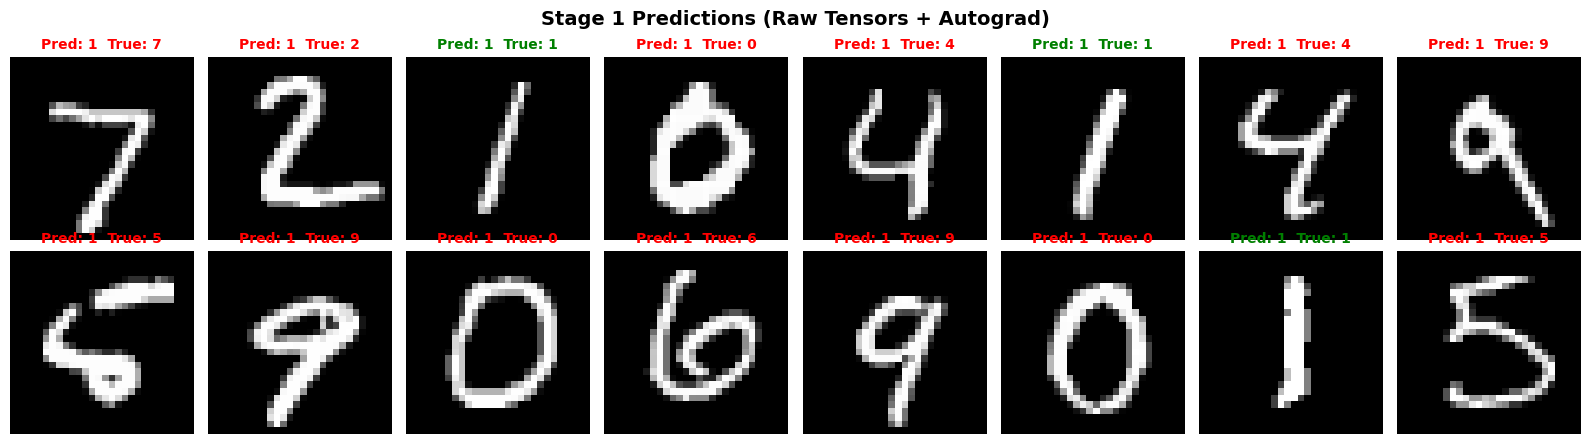

In [8]:
# Let's see some predictions!

with torch.no_grad():
    test_logits = forward_manual(X_test)
    test_preds = test_logits.argmax(dim=1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i, ax in enumerate(axes.flat):
    img = X_test[i].view(28, 28)
    pred = test_preds[i].item()
    true = y_test[i].item()
    ax.imshow(img, cmap='gray')
    color = 'green' if pred == true else 'red'
    ax.set_title(f'Pred: {pred}  True: {true}', fontsize=10, color=color, fontweight='bold')
    ax.axis('off')
plt.suptitle('Stage 1 Predictions (Raw Tensors + Autograd)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### What We Just Did (Stage 1 Recap)

We manually managed every single piece:

```python
# Created tensors by hand
W1 = torch.randn(784, 256, requires_grad=True)

# Wrote the forward pass by hand
z1 = x @ W1 + b1
a1 = z1.clamp(min=0)

# Updated weights by hand
p -= learning_rate * p.grad
p.grad.zero_()
```

This works, but it's **tedious and error-prone**. Imagine doing this with 50 layers!

What could go wrong:
- Forget `requires_grad=True` → no gradients
- Forget `p.grad.zero_()` → gradients accumulate across batches
- Typo in matrix dimensions → crash
- Forget `torch.no_grad()` during evaluation → wastes memory tracking unnecessary gradients

PyTorch's `nn.Module` solves all of this.

---

# Stage 2: The Same Network Using `nn.Module`

Now let's rebuild the **exact same architecture** (784 → 256 → 128 → 64 → 10) using PyTorch's `nn` module.

### What Changes and Why

| Manual (Stage 1) | `nn.Module` (Stage 2) | Why It's Better |
|------------------|-----------------------|----------------|
| `W1 = torch.randn(...)` | `nn.Linear(784, 256)` | Handles weight init, bias, shapes automatically |
| `z1 = x @ W1 + b1` | Built into `nn.Linear` | Can't get the shapes wrong |
| `z1.clamp(min=0)` | `F.relu(z1)` or `nn.ReLU()` | Clear, readable, swappable |
| `for p in params: p -= lr * p.grad` | `optimizer.step()` | One line, supports Adam/SGD/etc. |
| `p.grad.zero_()` | `optimizer.zero_grad()` | Can't forget individual params |
| Count params manually | `model.parameters()` | Automatic parameter tracking |

In [9]:
class MNISTNet(nn.Module):
    """
    Same architecture as Stage 1: 784 → 256 → 128 → 64 → 10
    But now using nn.Linear layers.
    
    nn.Linear(in, out) does exactly what we did manually:
        output = input @ W.T + b
    It creates W and b internally and registers them as parameters.
    """
    
    def __init__(self):
        super().__init__()
        
        # Each nn.Linear creates its own weight matrix and bias vector
        self.layer1 = nn.Linear(784, 256)   # 784 inputs → 256 outputs
        self.layer2 = nn.Linear(256, 128)   # 256 → 128
        self.layer3 = nn.Linear(128, 64)    # 128 → 64
        self.layer4 = nn.Linear(64, 10)     # 64 → 10 (output)
    
    def forward(self, x):
        """
        Same flow as our manual forward pass:
        Linear → ReLU → Linear → ReLU → Linear → ReLU → Linear
        """
        x = F.relu(self.layer1(x))   # Hidden 1 + activation
        x = F.relu(self.layer2(x))   # Hidden 2 + activation
        x = F.relu(self.layer3(x))   # Hidden 3 + activation
        x = self.layer4(x)           # Output (raw logits, no activation)
        return x


model = MNISTNet().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\n(Same count as Stage 1 — same architecture, cleaner code)")

MNISTNet(
  (layer1): Linear(in_features=784, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=64, bias=True)
  (layer4): Linear(in_features=64, out_features=10, bias=True)
)

Total parameters: 242,762

(Same count as Stage 1 — same architecture, cleaner code)


### Comparison: Manual vs `nn.Module`

```python
# ---- STAGE 1: Manual ----              # ---- STAGE 2: nn.Module ----
W1 = torch.randn(784,256) * scale        self.layer1 = nn.Linear(784, 256)
b1 = torch.zeros(256)                    # bias is automatic
W1.requires_grad_(True)                  # grad tracking is automatic

z1 = x @ W1 + b1                         x = self.layer1(x)
a1 = z1.clamp(min=0)                     x = F.relu(x)

for p in [W1,b1,W2,b2,...]:              optimizer = optim.SGD(model.parameters(), lr=0.01)
    p -= lr * p.grad                     optimizer.step()
    p.grad.zero_()                       optimizer.zero_grad()
```

Much cleaner. Same math underneath.

In [11]:
# ============================================================
# Training with nn.Module + Optimizer
# ============================================================
batch_size = 128

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

losses_stage2 = []

print("Training with nn.Module")
print("=" * 55)

start_time = time.time()

for epoch in range(epochs):
    epoch_loss = 0
    correct = 0
    total = 0
    
    perm = torch.randperm(X_train.size(0))
    n_batches = len(X_train) // batch_size
    
    for i in range(n_batches):
        idx = perm[i*batch_size : (i+1)*batch_size]
        X_batch = X_train[idx].to(device)
        y_batch = y_train[idx].to(device)
        
        # Forward
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)
        
        # Backward + Update — compare how clean this is vs Stage 1
        optimizer.zero_grad()   # Reset all gradients
        loss.backward()         # Compute all gradients
        optimizer.step()        # Update all parameters
        
        epoch_loss += loss.item()
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
    
    avg_loss = epoch_loss / n_batches
    train_acc = correct / total * 100
    losses_stage2.append(avg_loss)
    
    with torch.no_grad():
        test_logits = model(X_test.to(device))
        test_acc = (test_logits.argmax(1) == y_test.to(device)).float().mean().item() * 100
    
    print(f"  Epoch {epoch+1}/{epochs}  |  Loss: {avg_loss:.4f}  |  Train Acc: {train_acc:.1f}%  |  Test Acc: {test_acc:.1f}%")

elapsed = time.time() - start_time
print(f"\nDone in {elapsed:.1f}s — Final test accuracy: {test_acc:.1f}%")

Training with nn.Module
  Epoch 1/5  |  Loss: 2.2837  |  Train Acc: 21.4%  |  Test Acc: 36.6%
  Epoch 2/5  |  Loss: 2.1291  |  Train Acc: 51.7%  |  Test Acc: 60.0%
  Epoch 3/5  |  Loss: 1.2927  |  Train Acc: 68.9%  |  Test Acc: 78.2%
  Epoch 4/5  |  Loss: 0.6680  |  Train Acc: 80.4%  |  Test Acc: 83.8%
  Epoch 5/5  |  Loss: 0.5191  |  Train Acc: 84.8%  |  Test Acc: 86.7%

Done in 24.2s — Final test accuracy: 86.7%


The code is cleaner but the results are similar — because **the underlying math is identical**. `nn.Linear` does exactly the same matrix multiply + bias that we wrote by hand.

---

# Stage 3: The Proper Way — DataLoader, Adam, and Best Practices

In real projects, there are a few more things we add for better training:

| Practice | What | Why |
|----------|------|-----|
| `DataLoader` | Handles batching, shuffling, multi-worker loading | Cleaner, faster, correct shuffling |
| `Adam` optimizer | Adaptive learning rate per parameter | Converges faster than plain SGD |
| `model.train()` / `model.eval()` | Switch between training and eval mode | Some layers (Dropout, BatchNorm) behave differently during eval |
| Learning rate scheduler | Reduce LR over time | Fine-tune in later epochs |

In [12]:
class MNISTNetFinal(nn.Module):
    """
    Same architecture, but using nn.Sequential for even cleaner code.
    
    nn.Sequential chains layers automatically — the output of each
    layer is passed as input to the next. No need to write forward()
    step by step.
    """
    
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),               # nn.ReLU() as a layer vs F.relu() as a function — same thing
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )
    
    def forward(self, x):
        return self.network(x)


# Fresh model
model_final = MNISTNetFinal().to(device)

# Adam optimizer — adaptive learning rate, much faster convergence
optimizer = torch.optim.Adam(model_final.parameters(), lr=0.001)

# DataLoaders — handle batching and shuffling cleanly
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,       # Shuffle each epoch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False,
)

loss_fn = nn.CrossEntropyLoss()

print(model_final)
print(f"\nTotal parameters: {sum(p.numel() for p in model_final.parameters()):,}")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Batch size: 256")

MNISTNetFinal(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total parameters: 242,762
Optimizer: Adam (lr=0.001)
Batch size: 256


In [13]:
# ============================================================
# The standard PyTorch training loop
# ============================================================

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()  # Set to training mode
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in loader:
        # Flatten images: (batch, 1, 28, 28) → (batch, 784)
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)
        
        # Forward
        logits = model(images)
        loss = loss_fn(logits, labels)
        
        # Backward + Update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / total, correct / total * 100


def evaluate(model, loader, loss_fn, device):
    model.eval()  # Set to evaluation mode
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():  # No gradient computation needed for evaluation
        for images, labels in loader:
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)
            
            logits = model(images)
            loss = loss_fn(logits, labels)
            
            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / total, correct / total * 100

In [14]:
# Train!
epochs_final = 10

train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("Stage 3: Full PyTorch training pipeline")
print("=" * 65)

start_time = time.time()

for epoch in range(epochs_final):
    train_loss, train_acc = train_one_epoch(model_final, train_loader, optimizer, loss_fn, device)
    test_loss, test_acc = evaluate(model_final, test_loader, loss_fn, device)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(f"  Epoch {epoch+1:2d}/{epochs_final}  |  "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.1f}%  |  "
          f"Test Loss: {test_loss:.4f}  Acc: {test_acc:.1f}%")

elapsed = time.time() - start_time
print(f"\nDone in {elapsed:.1f}s — Final test accuracy: {test_accs[-1]:.1f}%")

Stage 3: Full PyTorch training pipeline
  Epoch  1/10  |  Train Loss: 0.5132  Acc: 85.3%  |  Test Loss: 0.2199  Acc: 93.8%
  Epoch  2/10  |  Train Loss: 0.1828  Acc: 94.7%  |  Test Loss: 0.1374  Acc: 96.0%
  Epoch  3/10  |  Train Loss: 0.1241  Acc: 96.4%  |  Test Loss: 0.1108  Acc: 96.6%
  Epoch  4/10  |  Train Loss: 0.0929  Acc: 97.2%  |  Test Loss: 0.1136  Acc: 96.5%
  Epoch  5/10  |  Train Loss: 0.0749  Acc: 97.7%  |  Test Loss: 0.0846  Acc: 97.5%
  Epoch  6/10  |  Train Loss: 0.0584  Acc: 98.2%  |  Test Loss: 0.0899  Acc: 97.2%
  Epoch  7/10  |  Train Loss: 0.0467  Acc: 98.6%  |  Test Loss: 0.0764  Acc: 97.8%
  Epoch  8/10  |  Train Loss: 0.0385  Acc: 98.8%  |  Test Loss: 0.0874  Acc: 97.4%
  Epoch  9/10  |  Train Loss: 0.0296  Acc: 99.1%  |  Test Loss: 0.0861  Acc: 97.5%
  Epoch 10/10  |  Train Loss: 0.0268  Acc: 99.1%  |  Test Loss: 0.0740  Acc: 97.9%

Done in 39.0s — Final test accuracy: 97.9%


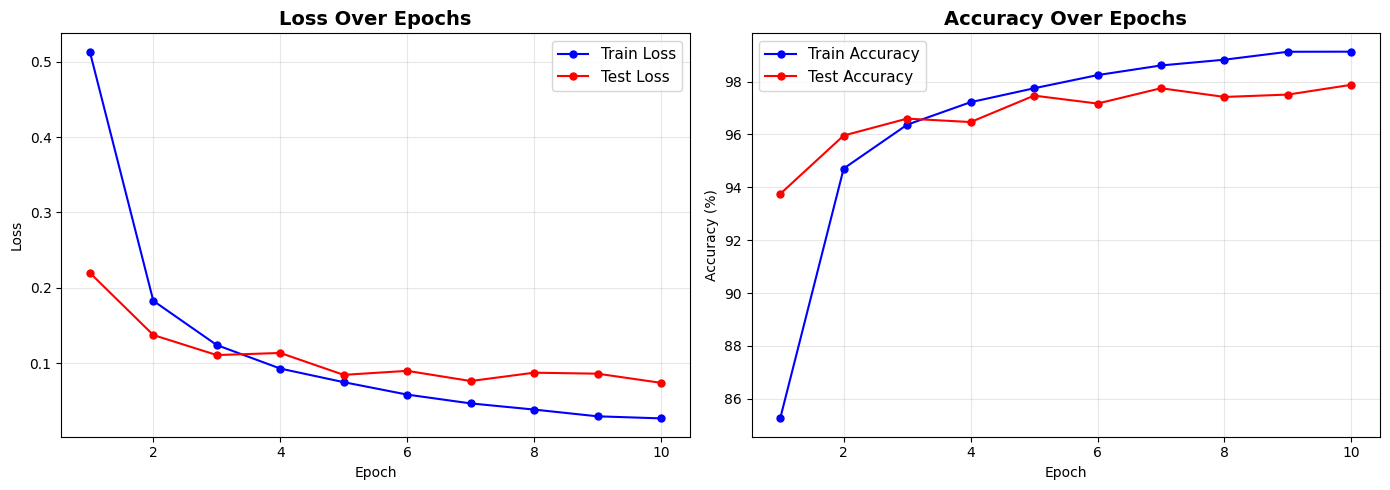

In [15]:
# Training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ep_range = range(1, epochs_final + 1)

axes[0].plot(ep_range, train_losses, 'b-o', label='Train Loss', markersize=5)
axes[0].plot(ep_range, test_losses, 'r-o', label='Test Loss', markersize=5)
axes[0].set_title('Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_range, train_accs, 'b-o', label='Train Accuracy', markersize=5)
axes[1].plot(ep_range, test_accs, 'r-o', label='Test Accuracy', markersize=5)
axes[1].set_title('Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

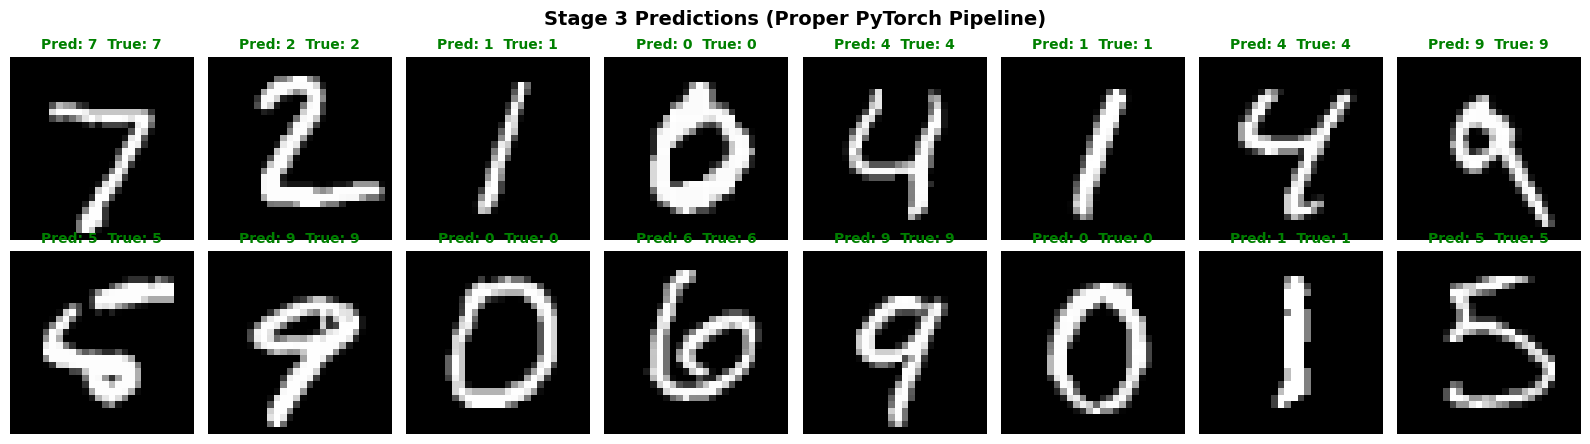

In [16]:
# Predictions on test set

model_final.eval()
with torch.no_grad():
    sample_images = test_dataset.data[:16].float() / 255.0
    sample_flat = sample_images.view(16, -1).to(device)
    preds = model_final(sample_flat).argmax(1).cpu()
    true_labels = test_dataset.targets[:16]

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i], cmap='gray')
    color = 'green' if preds[i] == true_labels[i] else 'red'
    ax.set_title(f'Pred: {preds[i].item()}  True: {true_labels[i].item()}',
                fontsize=10, color=color, fontweight='bold')
    ax.axis('off')
plt.suptitle('Stage 3 Predictions (Proper PyTorch Pipeline)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

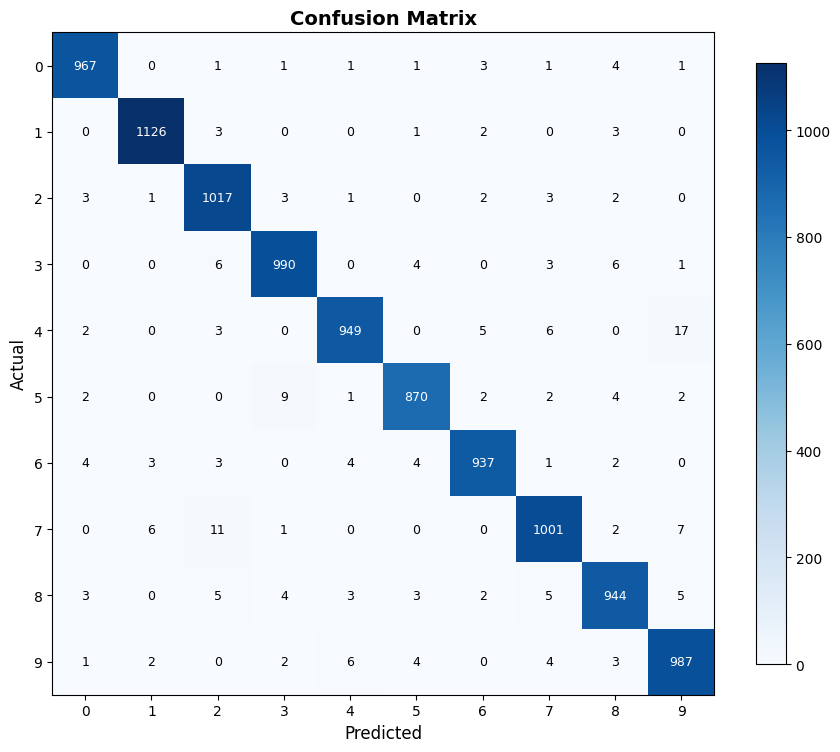

Per-digit accuracy:
  Digit 0: 98.7%
  Digit 1: 99.2%
  Digit 2: 98.5%
  Digit 3: 98.0%
  Digit 4: 96.6%
  Digit 5: 97.5%
  Digit 6: 97.8%
  Digit 7: 97.4%
  Digit 8: 96.9%
  Digit 9: 97.8%


In [17]:
# Confusion matrix — where does the model struggle?

from sklearn.metrics import confusion_matrix

model_final.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        preds = model_final(images).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Annotate cells
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() * 0.5 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("Per-digit accuracy:")
for digit in range(10):
    mask = all_labels == digit
    acc = (all_preds[mask] == digit).mean() * 100
    print(f"  Digit {digit}: {acc:.1f}%")

---

## Side-by-Side: The Three Stages

| | Stage 1: Raw Tensors | Stage 2: nn.Module | Stage 3: Full Pipeline |
|---|---|---|---|
| **Weights** | `torch.randn(..., requires_grad=True)` | `nn.Linear(in, out)` | Same as Stage 2 |
| **Forward** | `x @ W + b` then `.clamp(min=0)` | `F.relu(self.layer(x))` | `nn.Sequential(...)` |
| **Gradients** | `.backward()` | `.backward()` | `.backward()` |
| **Weight update** | Manual `p -= lr * p.grad` | `optimizer.step()` | `optimizer.step()` |
| **Batching** | Manual indexing | Manual indexing | `DataLoader` |
| **Optimizer** | SGD by hand | `optim.SGD` | `optim.Adam` |
| **When to use** | Learning / understanding | Small experiments | Production / real projects |

All three do the **same math**. The difference is how much bookkeeping PyTorch handles for you.

### What to Use in Practice

**Always use Stage 3** (or similar). The manual approach is for understanding — once you know what's happening underneath, there's no reason not to use the cleaner abstractions. `nn.Module` + `DataLoader` + `optimizer` is the standard PyTorch pattern you'll see in virtually every codebase.

In [18]:
# Save the trained model
torch.save(model_final.state_dict(), 'mnist_model.pth')
print("Model saved to mnist_model.pth")
print(f"File size: {torch.load('mnist_model.pth', weights_only=True).__len__()} parameter tensors")
print(f"\nTo load later:")
print(f"  model = MNISTNetFinal()")
print(f"  model.load_state_dict(torch.load('mnist_model.pth'))")

Model saved to mnist_model.pth
File size: 8 parameter tensors

To load later:
  model = MNISTNetFinal()
  model.load_state_dict(torch.load('mnist_model.pth'))
